# Filler vs Elaboration Length Effects on LLM Numeric-Answer Variance

This notebook is a runnable demo of `eval.py`, the evaluation script for the question:

**Does irrelevant-filler prompt padding increase LLM numeric-answer variance more than matched-length *relevant* elaboration, and is any of that mediated by logprob entropy?**

The upstream experiment ran GSM8K-style seed problems through three OpenAI models (`gpt-4.1-mini`, `gpt-4.1-nano`, `gpt-4o-mini`) under 7 prompt conditions per seed problem: a bare control, plus `irrelevant_filler` and `relevant_elaboration` text at `short`/`medium`/`long` length tiers (length-matched between the two content types). For each (model, seed problem, condition) cell it recorded the numeric-answer coefficient of variation (CV) across repeated samples and the mean logprob entropy of the first few generated tokens.

This demo runs the **exact same statistical pipeline** as `eval.py`:
1. Load the per-cell table and adapt it into a flat DataFrame (same adapter function as the original script).
2. Aggregate to per-prompt cells and compute answer CV.
3. **Metric 1** — paired Wilcoxon + cluster-bootstrap test: is filler CV higher than elaboration CV?
4. **Metric 2** — entropy precondition check (is entropy actually higher under filler?).
5. **Metric 3** — Baron-Kenny bootstrap mediation (does entropy mediate a length→CV relationship?).
6. **Metric 4** — confound/robustness checks (length matching, refusal-rate imbalance).

The demo uses a small curated subset of the real experiment data (4 of 16 seed problems, all models/conditions retained) so it runs in well under a minute. The config cell below shows how to scale back up to the full 16-seed-problem run.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# numpy, pandas, scipy are pre-installed on Colab; install locally to match Colab's exact versions
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
from __future__ import annotations

import json
import logging
import sys
from typing import Any

import numpy as np
import pandas as pd
from scipy import stats as sstats
import matplotlib.pyplot as plt

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    stream=sys.stdout,
)
log = logging.getLogger("eval")

## Load the demo data

Tries the GitHub-hosted `mini_demo_data.json` first (works once this artifact is published), then falls back to the local copy sitting next to this notebook (works right now, and in any local Jupyter run).

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-0e9809-interpretive-load-not-token-count-drives/main/round-1/evaluation-1/demo/mini_demo_data.json"
import os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL, timeout=10) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print("n_examples:", len(data["datasets"][0]["examples"]))
print("note:", data["metadata"].get("note_demo_subset"))

n_examples: 84
note: Curated demo subset: first 4 of 16 seed_problem_ids (all content_types/length_tiers/models retained) for a fast-running notebook demo.


## Config

All tunable parameters from the original `eval.py`, gathered here. `N_BOOT_PAIRED`/`N_BOOT_MEDIATION` control how many bootstrap resamples are drawn for the confidence intervals — the original script uses 10,000 / 5,000. For this fast demo we drop them to the smallest values that still produce a real (if noisy) CI; scale back up to the commented-out originals for a full run.

In [5]:
RNG_SEED = 20260819  # fixed for reproducibility (this run's date, not wall-clock)

# Demo (fast) values -- smallest that still produce a real bootstrap CI:
N_BOOT_PAIRED = 200      # original: 10_000
N_BOOT_MEDIATION = 200   # original: 5_000

ALPHA = 0.05

REQUIRED_COLS = {
    "model_id",
    "seed_problem_id",
    "content_type",
    "length_tier",
    "prompt_token_count",
}
ANSWER_COLS_PER_SAMPLE = {"numeric_answer"}
ANSWER_COLS_AGGREGATED = {"answer_mean", "answer_sd"}
ENTROPY_COLS = {"logprob_entropy", "attention_entropy", "entropy_mean"}

CONTENT_TYPE_MAP = {
    "relevant": "relevant_elaboration",
    "relevant_elaboration": "relevant_elaboration",
    "filler": "irrelevant_filler",
    "irrelevant_filler": "irrelevant_filler",
    "bare": "baseline",
    "baseline": "baseline",
    "control": "baseline",
    "none": "baseline",
}

## Adapt the raw experiment table into the evaluation's input contract

This is `_try_adapt_experiment_gen_sol_format` from the original `eval.py`, copied as-is. It recognizes the upstream experiment's `datasets -> examples` output shape (one row per (prompt_id, model) cell, already aggregated over that cell's repeated samples) and flattens it into the columns the rest of the pipeline expects: `model_id`, `seed_problem_id`, `content_type`, `length_tier`, `answer_mean`, `answer_sd`, `answer_cv`, `entropy_mean`, etc.

In [6]:
def _try_adapt_experiment_gen_sol_format(raw: dict) -> pd.DataFrame | None:
    """Adapt this run's actual gen_art_experiment_1 output schema (an
    exp_gen_sol_out-style datasets->examples table with per-example
    ``predict_our_method``/``metadata_*`` fields) into the flat per-prompt-
    cell column names this evaluation's input contract expects."""
    if "datasets" not in raw:
        return None
    flat_examples: list[dict] = []
    for ds in raw.get("datasets", []):
        flat_examples.extend(ds.get("examples", []))
    if not flat_examples:
        return None

    sample = flat_examples[0]
    if "predict_our_method" not in sample or "metadata_content_type" not in sample:
        return None

    rows = []
    for ex in flat_examples:
        prompt_id = ex.get("input", "")
        parts = prompt_id.split("_")
        seed_problem_id = "_".join(parts[:2]) if len(parts) >= 2 else prompt_id

        model_raw = ex.get("predict_our_method", "")
        model_id = model_raw.split("=", 1)[1] if "=" in model_raw else model_raw

        content_type_raw = str(ex.get("metadata_content_type", ""))
        content_type = CONTENT_TYPE_MAP.get(content_type_raw, content_type_raw)

        answer_variance = ex.get("metadata_answer_variance")
        answer_sd = float(answer_variance) ** 0.5 if isinstance(answer_variance, (int, float)) and answer_variance >= 0 else None

        entropy_val = ex.get("metadata_mean_logprob_entropy_first_k")
        entropy_col_used = "logprob_entropy"
        if entropy_val is None:
            entropy_val = ex.get("metadata_mean_attention_entropy_first_k")
            entropy_col_used = "attention_entropy"

        out_raw = ex.get("output", "")
        answer_mean = None
        try:
            out_parsed = json.loads(out_raw) if isinstance(out_raw, str) else out_raw
            if isinstance(out_parsed, dict):
                answer_mean = out_parsed.get("answer_mean")
        except (json.JSONDecodeError, TypeError):
            pass

        rows.append(
            {
                "model_id": model_id,
                "seed_problem_id": seed_problem_id,
                "prompt_id": prompt_id,
                "content_type": content_type,
                "length_tier": ex.get("metadata_length_tier"),
                "prompt_token_count": ex.get("metadata_token_count"),
                "answer_mean": answer_mean,
                "answer_sd": answer_sd,
                "answer_cv": ex.get("metadata_answer_cv"),
                "n_valid_samples": ex.get("metadata_n_valid_samples"),
                "frac_correct": ex.get("metadata_frac_correct"),
                "low_n_flag": ex.get("metadata_low_n_flag"),
                "entropy_mean": entropy_val,
                entropy_col_used: entropy_val,
            }
        )
    df = pd.DataFrame(rows)
    return df if not df.empty else None


def load_table_from_data(raw: dict) -> pd.DataFrame | None:
    """Same dispatch logic as eval.py's load_table(), but operating on an
    already-parsed dict (the notebook's `data`) instead of a file path."""
    if isinstance(raw, dict):
        adapted = _try_adapt_experiment_gen_sol_format(raw)
        if adapted is not None:
            log.info("Adapted data via known experiment output schema (%d rows)", len(adapted))
            return adapted

    rows: Any = None
    if isinstance(raw, list):
        rows = raw
    elif isinstance(raw, dict):
        for key in ("rows", "data", "table", "examples", "results", "prompts"):
            if key in raw and isinstance(raw[key], list):
                rows = raw[key]
                break
        if rows is None and "datasets" in raw:
            flat = []
            for ds in raw.get("datasets", []):
                for ex in ds.get("examples", []):
                    flat.append(ex)
            rows = flat

    if not rows:
        return None

    df = pd.DataFrame(rows)
    return df if not df.empty else None


df = load_table_from_data(data)
print(df.shape)
df.head()

2026-08-19 16:00:44,386 [INFO] Adapted data via known experiment output schema (84 rows)


(84, 14)


,model_id,seed_problem_id,prompt_id,content_type,length_tier,prompt_token_count,answer_mean,answer_sd,answer_cv,n_valid_samples,frac_correct,low_n_flag,entropy_mean,logprob_entropy
0,openai/gpt-4.1-mini,seed_000,seed_000_bare_bare,baseline,bare,57,10.0,0.000000,0.000000,20,1.00,False,0.284141,0.284141
1,openai/gpt-4.1-nano,seed_000,seed_000_bare_bare,baseline,bare,57,10.0,0.000000,0.000000,20,1.00,False,0.372843,0.372843
2,openai/gpt-4o-mini,seed_000,seed_000_bare_bare,baseline,bare,57,10.0,0.000000,0.000000,14,1.00,False,0.205828,0.205828
3,openai/gpt-4.1-mini,seed_000,seed_000_filler_long,irrelevant_filler,long,714,10.0,0.000000,0.000000,20,1.00,False,0.297367,0.297367
4,openai/gpt-4.1-nano,seed_000,seed_000_filler_long,irrelevant_filler,long,714,9.6,1.788854,0.186339,20,0.95,False,0.339961,0.339961


## Validate the input contract

Same check as `eval.py`'s `validate_input_contract`: confirm the required grouping columns are present, and that we have either per-sample or pre-aggregated answer columns, plus an entropy column.

In [7]:
def validate_input_contract(df: pd.DataFrame) -> tuple[bool, list[str]]:
    """Check the loaded table against the plan's INPUT CONTRACT."""
    problems: list[str] = []
    missing_required = REQUIRED_COLS - set(df.columns)
    if missing_required:
        problems.append(f"missing required columns: {sorted(missing_required)}")

    has_per_sample_answer = bool(ANSWER_COLS_PER_SAMPLE & set(df.columns))
    has_aggregated_answer = ANSWER_COLS_AGGREGATED.issubset(set(df.columns))
    if not (has_per_sample_answer or has_aggregated_answer):
        problems.append(
            "no usable answer columns: need 'numeric_answer' (per-sample) or "
            "both 'answer_mean' and 'answer_sd' (pre-aggregated)"
        )

    has_entropy = bool(ENTROPY_COLS & set(df.columns))
    if not has_entropy:
        problems.append(
            "no entropy column found: need one of "
            f"{sorted(ENTROPY_COLS)} to test the mediation hypothesis"
        )

    return (len(problems) == 0), problems


ok, problems = validate_input_contract(df)
print("contract satisfied:", ok, problems)
assert ok

contract satisfied: True []


## Aggregate to per-prompt cells

Each row is already one (model, seed problem, content type, length tier) cell, so this mainly derives `answer_cv = answer_sd / |answer_mean|` and excludes cells where CV is undefined (mean is 0, e.g. a perfectly-answered bare-control cell).

In [8]:
def aggregate_to_per_prompt(df: pd.DataFrame) -> tuple[pd.DataFrame, dict[str, Any]]:
    """Aggregate a per-sample table to one row per prompt cell."""
    exclusions: dict[str, Any] = {"cv_undefined_excluded": [], "refusal_rates": {}}

    group_keys = [c for c in ("model_id", "seed_problem_id", "content_type", "length_tier") if c in df.columns]

    entropy_col = next((c for c in ("entropy_mean", "logprob_entropy", "attention_entropy") if c in df.columns), None)

    if "numeric_answer" in df.columns:
        raise NotImplementedError("demo data is pre-aggregated (has answer_mean/answer_sd), not per-sample")
    else:
        agg = df.copy()
        if entropy_col and entropy_col != "entropy_mean":
            agg["entropy_mean"] = agg[entropy_col]
        if "n_valid_samples" not in agg.columns:
            agg["n_valid_samples"] = np.nan
        if "refusal_rate" not in agg.columns:
            agg["refusal_rate"] = np.nan

    def _safe_cv(row) -> float | None:
        m, s = row.get("answer_mean"), row.get("answer_sd")
        if m is None or s is None or pd.isna(m) or pd.isna(s):
            return None
        if abs(m) < 1e-9:
            return None
        return float(s) / abs(float(m))

    agg["answer_cv"] = agg.apply(_safe_cv, axis=1)
    n_before = len(agg)
    undefined = agg[agg["answer_cv"].isna()]
    for _, r in undefined.iterrows():
        exclusions["cv_undefined_excluded"].append(
            {
                "seed_problem_id": r.get("seed_problem_id"),
                "model_id": r.get("model_id"),
                "content_type": r.get("content_type"),
                "length_tier": r.get("length_tier"),
                "reason": "answer_mean is 0 or missing sd/mean -> CV undefined",
            }
        )
    exclusions["n_cells_before_cv_filter"] = n_before
    exclusions["n_cells_excluded_cv_undefined"] = len(undefined)
    agg = agg[agg["answer_cv"].notna()].reset_index(drop=True)
    return agg, exclusions


agg, exclusions = aggregate_to_per_prompt(df)
print(f"Aggregated to {len(agg)} per-prompt cells ({exclusions['n_cells_excluded_cv_undefined']} excluded for CV-undefined)")
agg[["model_id", "seed_problem_id", "content_type", "length_tier", "answer_cv", "entropy_mean"]].head(10)

Aggregated to 84 per-prompt cells (0 excluded for CV-undefined)


,model_id,seed_problem_id,content_type,length_tier,answer_cv,entropy_mean
0,openai/gpt-4.1-mini,seed_000,baseline,bare,0.000000,0.284141
1,openai/gpt-4.1-nano,seed_000,baseline,bare,0.000000,0.372843
2,openai/gpt-4o-mini,seed_000,baseline,bare,0.000000,0.205828
3,openai/gpt-4.1-mini,seed_000,irrelevant_filler,long,0.000000,0.297367
4,openai/gpt-4.1-nano,seed_000,irrelevant_filler,long,0.186339,0.339961
5,openai/gpt-4o-mini,seed_000,irrelevant_filler,long,0.000000,0.200735
6,openai/gpt-4.1-mini,seed_000,irrelevant_filler,medium,0.000000,0.262325
7,openai/gpt-4.1-nano,seed_000,irrelevant_filler,medium,0.154291,0.349515
8,openai/gpt-4o-mini,seed_000,irrelevant_filler,medium,0.000000,0.174880
9,openai/gpt-4.1-mini,seed_000,irrelevant_filler,short,0.000000,0.262009


## Statistical primitives

Paired bootstrap CI, paired Wilcoxon test, sign test, and Holm-Bonferroni correction — copied unchanged from `eval.py`. These are the building blocks used by all four metrics below.

In [9]:
def paired_bootstrap_ci(
    diffs: np.ndarray, n_boot: int, rng: np.random.Generator, alpha: float = ALPHA
) -> dict[str, float]:
    if len(diffs) == 0:
        return {"mean": float("nan"), "ci_lo": float("nan"), "ci_hi": float("nan"), "n": 0}
    boots = np.empty(n_boot)
    n = len(diffs)
    idx_all = rng.integers(0, n, size=(n_boot, n))
    for i in range(n_boot):
        boots[i] = diffs[idx_all[i]].mean()
    lo, hi = np.percentile(boots, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return {"mean": float(diffs.mean()), "ci_lo": float(lo), "ci_hi": float(hi), "n": int(n)}


def wilcoxon_paired(x: np.ndarray, y: np.ndarray) -> dict[str, Any]:
    d = x - y
    d_nz = d[d != 0]
    if len(d_nz) < 1:
        return {"statistic": None, "p_value": 1.0, "rank_biserial_r": 0.0, "n_nonzero": 0}
    try:
        res = sstats.wilcoxon(x, y, zero_method="wilcox", alternative="two-sided", mode="auto")
        stat, p = float(res.statistic), float(res.pvalue)
    except ValueError:
        return {"statistic": None, "p_value": 1.0, "rank_biserial_r": 0.0, "n_nonzero": int(len(d_nz))}
    n = len(d_nz)
    ranks = sstats.rankdata(np.abs(d_nz))
    w_plus = ranks[d_nz > 0].sum()
    w_minus = ranks[d_nz < 0].sum()
    r_rb = (w_plus - w_minus) / (w_plus + w_minus) if (w_plus + w_minus) > 0 else 0.0
    return {"statistic": stat, "p_value": p, "rank_biserial_r": float(r_rb), "n_nonzero": int(n)}


def sign_test(x: np.ndarray, y: np.ndarray) -> dict[str, Any]:
    d = x - y
    d_nz = d[d != 0]
    n = len(d_nz)
    if n == 0:
        return {"n_pairs": 0, "n_positive": 0, "fraction_positive": float("nan"), "ci_lo": None, "ci_hi": None}
    k = int((d_nz > 0).sum())
    res = sstats.binomtest(k, n, p=0.5)
    ci = res.proportion_ci(confidence_level=1 - ALPHA)
    return {
        "n_pairs": int(n),
        "n_positive": k,
        "fraction_positive": k / n,
        "ci_lo": float(ci.low),
        "ci_hi": float(ci.high),
        "binom_p_value": float(res.pvalue),
    }


def holm_bonferroni(pvals: list[float]) -> list[float]:
    """Holm-Bonferroni step-down correction. Returns adjusted p-values in original order."""
    m = len(pvals)
    if m == 0:
        return []
    order = np.argsort(pvals)
    adj = np.empty(m)
    running_max = 0.0
    for rank, idx in enumerate(order):
        corrected = (m - rank) * pvals[idx]
        running_max = max(running_max, corrected)
        adj[idx] = min(running_max, 1.0)
    return adj.tolist()


def breusch_pagan(resid: np.ndarray, x: np.ndarray) -> dict[str, float]:
    """Simple Breusch-Pagan heteroscedasticity test for a single regressor."""
    n = len(resid)
    if n < 4:
        return {"lm_stat": float("nan"), "p_value": float("nan")}
    sigma2 = np.mean(resid**2)
    if sigma2 <= 0:
        return {"lm_stat": float("nan"), "p_value": float("nan")}
    g = (resid**2) / sigma2
    X = np.column_stack([np.ones(n), x])
    beta, *_ = np.linalg.lstsq(X, g, rcond=None)
    g_hat = X @ beta
    ss_reg = float(np.sum((g_hat - g.mean()) ** 2))
    ss_tot = float(np.sum((g - g.mean()) ** 2))
    r2 = ss_reg / ss_tot if ss_tot > 0 else 0.0
    lm = n * r2
    p = float(1 - sstats.chi2.cdf(lm, df=1))
    return {"lm_stat": float(lm), "p_value": p}


def ols_1var(y: np.ndarray, x: np.ndarray) -> dict[str, Any]:
    """OLS y ~ 1 + x. Returns intercept, slope, residuals, fitted."""
    n = len(y)
    X = np.column_stack([np.ones(n), x])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    fitted = X @ beta
    resid = y - fitted
    return {"intercept": float(beta[0]), "slope": float(beta[1]), "resid": resid, "fitted": fitted}


def ols_2var(y: np.ndarray, x1: np.ndarray, x2: np.ndarray) -> dict[str, Any]:
    """OLS y ~ 1 + x1 + x2."""
    n = len(y)
    X = np.column_stack([np.ones(n), x1, x2])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    fitted = X @ beta
    resid = y - fitted
    return {"intercept": float(beta[0]), "b_x1": float(beta[1]), "b_x2": float(beta[2]), "resid": resid}


def zscore(a: np.ndarray) -> np.ndarray:
    sd = a.std(ddof=1)
    if sd < 1e-12:
        return np.zeros_like(a)
    return (a - a.mean()) / sd


rng = np.random.default_rng(RNG_SEED)

## Metric 1: paired filler-vs-elaboration variance comparison

For each (model, length_tier) pair, and pooled overall, this pairs up `irrelevant_filler` and `relevant_elaboration` cells on the shared `seed_problem_id` and asks: is the CV higher under filler? A paired Wilcoxon test plus a cluster-bootstrap CI (resampling whole `seed_problem_id` clusters, since a seed problem's filler/elaboration cells across length tiers/models are not independent) give the answer.

In [10]:
def metric1_paired_cv(agg: pd.DataFrame, rng: np.random.Generator) -> dict[str, Any]:
    out: dict[str, Any] = {"per_cell": [], "pooled_per_model": [], "pooled_overall": None}

    filler = agg[agg["content_type"] == "irrelevant_filler"]
    elab = agg[agg["content_type"] == "relevant_elaboration"]

    cell_results = []
    for (model, tier), fgrp in filler.groupby(["model_id", "length_tier"], dropna=False):
        egrp = elab[(elab["model_id"] == model) & (elab["length_tier"] == tier)]
        merged = fgrp.merge(egrp, on="seed_problem_id", suffixes=("_filler", "_elab"))
        if merged.empty:
            continue
        d = (merged["answer_cv_filler"] - merged["answer_cv_elab"]).to_numpy()
        wilc = wilcoxon_paired(merged["answer_cv_filler"].to_numpy(), merged["answer_cv_elab"].to_numpy())
        boot = paired_bootstrap_ci(d, N_BOOT_PAIRED, rng)
        sgn = sign_test(merged["answer_cv_filler"].to_numpy(), merged["answer_cv_elab"].to_numpy())
        cell_results.append(
            {
                "model_id": model,
                "length_tier": tier,
                "n_pairs": int(len(merged)),
                "wilcoxon": wilc,
                "bootstrap_mean_diff_ci": boot,
                "sign_test": sgn,
                "meets_criterion1_uncorrected": bool(boot["mean"] > 0 and wilc["p_value"] < ALPHA),
            }
        )

    pvals = [c["wilcoxon"]["p_value"] for c in cell_results]
    adj = holm_bonferroni(pvals)
    for c, p_adj in zip(cell_results, adj):
        c["wilcoxon"]["p_value_holm"] = p_adj
        c["meets_criterion1_corrected"] = bool(c["bootstrap_mean_diff_ci"]["mean"] > 0 and p_adj < ALPHA)
        c["reverse_direction_flag"] = bool(c["bootstrap_mean_diff_ci"]["mean"] < 0 and p_adj < ALPHA)
    out["per_cell"] = cell_results

    for model, fgrp in filler.groupby("model_id"):
        egrp = elab[elab["model_id"] == model]
        merged = fgrp.merge(egrp, on="seed_problem_id", suffixes=("_filler", "_elab"))
        if merged.empty:
            continue
        d = (merged["answer_cv_filler"] - merged["answer_cv_elab"]).to_numpy()
        wilc = wilcoxon_paired(merged["answer_cv_filler"].to_numpy(), merged["answer_cv_elab"].to_numpy())
        boot = paired_bootstrap_ci(d, N_BOOT_PAIRED, rng)
        out["pooled_per_model"].append(
            {"model_id": model, "n_pairs": int(len(merged)), "wilcoxon": wilc, "bootstrap_mean_diff_ci": boot}
        )

    merged_all = filler.merge(elab, on=["seed_problem_id", "model_id"], suffixes=("_filler", "_elab"))
    if not merged_all.empty:
        seed_ids = merged_all["seed_problem_id"].unique()
        cluster_diffs = merged_all.groupby("seed_problem_id").apply(
            lambda g: (g["answer_cv_filler"] - g["answer_cv_elab"]).mean()
        )
        d_all = cluster_diffs.to_numpy()
        boot = paired_bootstrap_ci(d_all, N_BOOT_PAIRED, rng)
        wilc = wilcoxon_paired(
            merged_all["answer_cv_filler"].to_numpy(), merged_all["answer_cv_elab"].to_numpy()
        )
        out["pooled_overall"] = {
            "n_cluster_seed_problems": int(len(seed_ids)),
            "n_rows_pooled": int(len(merged_all)),
            "wilcoxon_row_level": wilc,
            "cluster_bootstrap_mean_diff_ci": boot,
            "note": "cluster_bootstrap resamples seed_problem_id clusters (mean CV-diff per seed_problem) "
            "to respect non-independence across length_tier/model repeats of the same seed problem",
        }
    return out


m1 = metric1_paired_cv(agg, rng)
print("Metric 1 pooled_overall:", json.dumps(m1["pooled_overall"], indent=2))

Metric 1 pooled_overall: {
  "n_cluster_seed_problems": 4,
  "n_rows_pooled": 108,
  "wilcoxon_row_level": {
    "statistic": 184.0,
    "p_value": 0.0013979505988417473,
    "rank_biserial_r": -0.5725900116144018,
    "n_nonzero": 41
  },
  "cluster_bootstrap_mean_diff_ci": {
    "mean": -0.0832043905898156,
    "ci_lo": -0.3151272731009068,
    "ci_hi": 0.06158470805880128,
    "n": 4
  },
  "note": "cluster_bootstrap resamples seed_problem_id clusters (mean CV-diff per seed_problem) to respect non-independence across length_tier/model repeats of the same seed problem"
}


/tmp/ipykernel_659/2287294637.py:52: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cluster_diffs = merged_all.groupby("seed_problem_id").apply(


## Metric 2: entropy precondition check

For the mediation hypothesis (Metric 3) to even be plausible, entropy needs to actually differ between filler and elaboration cells. This checks, per (model, length_tier), whether filler entropy is significantly higher than elaboration entropy.

In [11]:
def metric2_entropy_precondition(agg: pd.DataFrame, rng: np.random.Generator) -> dict[str, Any]:
    if "entropy_mean" not in agg.columns:
        return {"status": "NO_ENTROPY_COLUMN", "per_cell": []}
    out: dict[str, Any] = {"per_cell": []}
    filler = agg[agg["content_type"] == "irrelevant_filler"]
    elab = agg[agg["content_type"] == "relevant_elaboration"]
    for (model, tier), fgrp in filler.groupby(["model_id", "length_tier"], dropna=False):
        egrp = elab[(elab["model_id"] == model) & (elab["length_tier"] == tier)]
        merged = fgrp.merge(egrp, on="seed_problem_id", suffixes=("_filler", "_elab")).dropna(
            subset=["entropy_mean_filler", "entropy_mean_elab"]
        )
        if merged.empty:
            continue
        d = (merged["entropy_mean_filler"] - merged["entropy_mean_elab"]).to_numpy()
        wilc = wilcoxon_paired(merged["entropy_mean_filler"].to_numpy(), merged["entropy_mean_elab"].to_numpy())
        boot = paired_bootstrap_ci(d, N_BOOT_PAIRED, rng)
        out["per_cell"].append(
            {
                "model_id": model,
                "length_tier": tier,
                "n_pairs": int(len(merged)),
                "wilcoxon": wilc,
                "bootstrap_mean_diff_ci": boot,
                "entropy_higher_for_filler": bool(boot["mean"] > 0 and wilc["p_value"] < ALPHA),
            }
        )
    return out


m2 = metric2_entropy_precondition(agg, rng)
n_precond_pass = sum(1 for c in m2.get("per_cell", []) if c.get("entropy_higher_for_filler"))
print(f"Metric 2: {n_precond_pass}/{len(m2['per_cell'])} cells show entropy_higher_for_filler")

Metric 2: 0/9 cells show entropy_higher_for_filler


## Metric 3: bootstrap mediation analysis (Baron-Kenny)

Tests whether logprob entropy mediates a relationship between prompt length and answer CV, via a standardized Baron-Kenny mediation model with a cluster-bootstrap CI on the indirect effect `a*b` (resampling `seed_problem_id` clusters). Requires at least 8 rows and 4 distinct seed problems per group to run at all -- with only 4 seed problems in this demo subset, expect `pooled` to come back `None` (exactly the small-sample scope limitation the original run also hits). Scale `N_BOOT_MEDIATION` and the number of seed problems in the data back up for a real mediation estimate.

In [12]:
def length_tier_numeric(agg: pd.DataFrame) -> np.ndarray:
    if "prompt_token_count" in agg.columns and agg["prompt_token_count"].notna().all():
        return agg["prompt_token_count"].to_numpy(dtype=float)
    tiers = agg["length_tier"].astype(str)
    order = {"none": 0, "bare": 0, "control": 0, "short": 1, "medium": 2, "long": 3}
    return tiers.map(lambda t: order.get(t.lower(), np.nan)).to_numpy(dtype=float)


def run_mediation(sub: pd.DataFrame, n_boot: int, rng: np.random.Generator, label: str) -> dict[str, Any] | None:
    sub = sub.dropna(subset=["answer_cv", "entropy_mean"]).copy()
    if len(sub) < 8 or sub["seed_problem_id"].nunique() < 4:
        return None
    x_raw = length_tier_numeric(sub)
    y_raw = sub["answer_cv"].to_numpy(dtype=float)
    m_raw = sub["entropy_mean"].to_numpy(dtype=float)
    valid = np.isfinite(x_raw) & np.isfinite(y_raw) & np.isfinite(m_raw)
    x_raw, y_raw, m_raw = x_raw[valid], y_raw[valid], m_raw[valid]
    sub = sub.loc[valid]
    if len(x_raw) < 8:
        return None

    x, y, m = zscore(x_raw), zscore(y_raw), zscore(m_raw)

    total = ols_1var(y, x)
    c = total["slope"]
    med_model = ols_1var(m, x)
    a = med_model["slope"]
    out_model = ols_2var(y, x, m)
    b, c_prime = out_model["b_x2"], out_model["b_x1"]

    bp = breusch_pagan(total["resid"], x)
    log_transform_used = False
    if bp["p_value"] < ALPHA and (y_raw > 0).all():
        log_transform_used = True
        y_log = zscore(np.log(y_raw))
        total_log = ols_1var(y_log, x)
        out_model_log = ols_2var(y_log, x, m)
        c_log, b_log, c_prime_log = total_log["slope"], out_model_log["b_x2"], out_model_log["b_x1"]
        ab_log = a * b_log
    else:
        ab_log = None

    seed_ids = sub["seed_problem_id"].unique()
    id_to_rows: dict[Any, np.ndarray] = {
        sid: np.where(sub["seed_problem_id"].to_numpy() == sid)[0] for sid in seed_ids
    }
    ab_boots = np.empty(n_boot)
    n_clusters = len(seed_ids)
    for i in range(n_boot):
        sampled_ids = rng.choice(seed_ids, size=n_clusters, replace=True)
        rows = np.concatenate([id_to_rows[sid] for sid in sampled_ids])
        xb, yb, mb = zscore(x_raw[rows]), zscore(y_raw[rows]), zscore(m_raw[rows])
        try:
            a_b = ols_1var(mb, xb)["slope"]
            out_b = ols_2var(yb, xb, mb)
            ab_boots[i] = a_b * out_b["b_x2"]
        except np.linalg.LinAlgError:
            ab_boots[i] = np.nan
    ab_boots = ab_boots[np.isfinite(ab_boots)]
    if len(ab_boots) < n_boot * 0.5:
        ab_ci = (float("nan"), float("nan"))
    else:
        ab_ci = tuple(np.percentile(ab_boots, [2.5, 97.5]))

    ab_point = a * b
    prop_mediated = ab_point / c if abs(c) > 1e-9 else float("nan")

    ci_excludes_zero = bool(ab_ci[0] > 0 or ab_ci[1] < 0) if np.isfinite(ab_ci[0]) else False
    if not ci_excludes_zero:
        verdict = "NOT_MEDIATED"
    elif abs(prop_mediated) < 0.20 or not np.isfinite(prop_mediated):
        verdict = "PARTIALLY_MEDIATED"
    else:
        verdict = "MEDIATED"

    return {
        "label": label,
        "n_rows": int(len(sub)),
        "n_seed_problem_clusters": int(n_clusters),
        "standardized_coefs": {"c_total": float(c), "a_mediator": float(a), "b_outcome": float(b), "c_prime_direct": float(c_prime)},
        "raw_scale_coefs": {"c_total": float(total["slope"]), "b_outcome_raw_approx": float(b) * (y_raw.std(ddof=1) / (m_raw.std(ddof=1) or 1))},
        "indirect_effect_ab": float(ab_point),
        "indirect_effect_bootstrap_ci95": [float(ab_ci[0]), float(ab_ci[1])],
        "n_boot_used": int(len(ab_boots)),
        "proportion_mediated": float(prop_mediated) if np.isfinite(prop_mediated) else None,
        "breusch_pagan_cv_vs_length": bp,
        "log_transform_sensitivity_used": log_transform_used,
        "log_transform_indirect_effect_ab": float(ab_log) if ab_log is not None else None,
        "verdict": verdict,
    }


def metric3_mediation(agg: pd.DataFrame, rng: np.random.Generator) -> dict[str, Any]:
    if "entropy_mean" not in agg.columns:
        return {"status": "NO_ENTROPY_COLUMN", "pooled": None, "per_model": []}
    pooled = run_mediation(agg, N_BOOT_MEDIATION, rng, "pooled_all_models")
    per_model = []
    for model, sub in agg.groupby("model_id"):
        r = run_mediation(sub, N_BOOT_MEDIATION, rng, f"model={model}")
        if r is not None:
            per_model.append(r)
    return {"pooled": pooled, "per_model": per_model}


m3 = metric3_mediation(agg, rng)
print("Metric 3 pooled verdict:", m3["pooled"]["verdict"] if m3["pooled"] else "UNAVAILABLE (too few seed problems in demo subset)")
print("Metric 3 per-model results computed:", len(m3["per_model"]))

Metric 3 pooled verdict: NOT_MEDIATED
Metric 3 per-model results computed: 3


## Metric 4: confound / robustness checks

Checks the experimental design assumptions: are filler and elaboration prompts actually length-matched within 15% per tier, is there a refusal-rate imbalance between conditions, and (if both entropy proxies were available) how correlated are they.

In [13]:
def metric4_confounds(agg: pd.DataFrame) -> dict[str, Any]:
    out: dict[str, Any] = {}

    tok_stats = (
        agg.groupby(["length_tier", "content_type"], dropna=False)["prompt_token_count"]
        .agg(["mean", "std", "count"])
        .reset_index()
        .to_dict(orient="records")
    )
    out["token_count_by_tier_and_type"] = tok_stats

    length_match_flags = []
    for tier, sub in agg.groupby("length_tier"):
        f = sub[sub["content_type"] == "irrelevant_filler"]["prompt_token_count"]
        e = sub[sub["content_type"] == "relevant_elaboration"]["prompt_token_count"]
        if len(f) == 0 or len(e) == 0:
            continue
        rel_diff = abs(f.mean() - e.mean()) / max(abs(e.mean()), 1e-9)
        length_match_flags.append(
            {
                "length_tier": tier,
                "filler_mean_tokens": float(f.mean()),
                "elaboration_mean_tokens": float(e.mean()),
                "relative_diff": float(rel_diff),
                "length_matched_within_15pct": bool(rel_diff <= 0.15),
            }
        )
    out["length_match_check"] = length_match_flags
    out["length_match_violated"] = any(not r["length_matched_within_15pct"] for r in length_match_flags)

    if "refusal_rate" in agg.columns:
        refusal = (
            agg.groupby(["model_id", "length_tier", "content_type"], dropna=False)["refusal_rate"]
            .mean()
            .reset_index()
            .to_dict(orient="records")
        )
        out["refusal_rate_by_cell"] = refusal
        f_ref = agg[agg["content_type"] == "irrelevant_filler"]["refusal_rate"].mean()
        e_ref = agg[agg["content_type"] == "relevant_elaboration"]["refusal_rate"].mean()
        ratio = (f_ref / e_ref) if (e_ref and e_ref > 0) else float("nan")
        out["refusal_rate_imbalance"] = {
            "filler_mean_refusal": float(f_ref) if pd.notna(f_ref) else None,
            "elaboration_mean_refusal": float(e_ref) if pd.notna(e_ref) else None,
            "ratio_filler_over_elaboration": float(ratio) if np.isfinite(ratio) else None,
            "imbalance_flag_gt_2x": bool(np.isfinite(ratio) and (ratio > 2 or ratio < 0.5)),
        }
    else:
        out["refusal_rate_by_cell"] = []
        out["refusal_rate_imbalance"] = None

    if "entropy_mean" in agg.columns:
        model_family_col = "model_id"
        model_summ = []
        for model, sub in agg.groupby(model_family_col):
            n = sub["seed_problem_id"].nunique()
            model_summ.append({"model_id": model, "n_seed_problems": int(n), "n_rows": int(len(sub))})
        out["model_comparison_scope"] = model_summ
    else:
        out["model_comparison_scope"] = []

    has_attention = "attention_entropy" in agg.columns
    has_logprob = "logprob_entropy" in agg.columns
    if has_attention and has_logprob:
        both = agg.dropna(subset=["attention_entropy", "logprob_entropy"])
        if len(both) >= 3:
            corr = float(np.corrcoef(both["attention_entropy"], both["logprob_entropy"])[0, 1])
        else:
            corr = None
        out["entropy_proxy_correlation"] = {"n_overlap": int(len(both)), "pearson_r": corr}
    else:
        out["entropy_proxy_correlation"] = {
            "status": "SCOPE_LIMITATION_SINGLE_ENTROPY_TYPE",
            "has_attention_entropy": has_attention,
            "has_logprob_entropy": has_logprob,
        }
    return out


m4 = metric4_confounds(agg)
print("length_match_violated:", m4["length_match_violated"])
print("length_match_check:", json.dumps(m4["length_match_check"], indent=2))

length_match_violated: False
length_match_check: [
  {
    "length_tier": "long",
    "filler_mean_tokens": 717.75,
    "elaboration_mean_tokens": 714.75,
    "relative_diff": 0.004197271773347324,
    "length_matched_within_15pct": true
  },
  {
    "length_tier": "medium",
    "filler_mean_tokens": 322.75,
    "elaboration_mean_tokens": 322.5,
    "relative_diff": 0.0007751937984496124,
    "length_matched_within_15pct": true
  },
  {
    "length_tier": "short",
    "filler_mean_tokens": 149.75,
    "elaboration_mean_tokens": 148.5,
    "relative_diff": 0.008417508417508417,
    "length_matched_within_15pct": true
  }
]


## Combine into a final verdict

`CONFIRMED` requires criterion 1 (filler CV significantly higher, cluster-bootstrap CI excludes 0 and is positive) AND criterion 2 (entropy mediation) AND length-matching to all hold; `PARTIALLY_CONFIRMED` if some but not all hold without a flagged reverse effect; otherwise `DISCONFIRMED`.

In [14]:
def combine_verdict(m1: dict, m2: dict, m3: dict, m4: dict) -> tuple[str, str]:
    overall = m1.get("pooled_overall")
    crit1_holds = bool(
        overall
        and overall["cluster_bootstrap_mean_diff_ci"]["ci_lo"] > 0
    )
    crit1_reverse_flagged = any(c.get("reverse_direction_flag") for c in m1.get("per_cell", []))

    pooled_med = m3.get("pooled")
    crit2_holds = bool(pooled_med and pooled_med["verdict"] == "MEDIATED")
    crit2_partial = bool(pooled_med and pooled_med["verdict"] == "PARTIALLY_MEDIATED")

    length_matched = not m4.get("length_match_violated", True)

    rationale_parts = [
        f"criterion1 (filler>elaboration CV, cluster-bootstrap CI on pooled paired diff excludes 0 and is positive): {crit1_holds}.",
        f"criterion1 reverse-direction cells flagged at Holm-corrected p<0.05: {crit1_reverse_flagged}.",
        f"criterion2 (entropy mediates length->CV, pooled Baron-Kenny bootstrap verdict): {pooled_med['verdict'] if pooled_med else 'UNAVAILABLE'}.",
        f"length-matched-prompts precondition (filler/elaboration within 15% tokens per tier): {length_matched}.",
    ]

    if crit1_holds and crit2_holds and length_matched:
        verdict = "CONFIRMED"
    elif (crit1_holds or crit2_holds or crit2_partial) and not (crit1_reverse_flagged and not crit1_holds):
        verdict = "PARTIALLY_CONFIRMED"
    else:
        verdict = "DISCONFIRMED"

    return verdict, " ".join(rationale_parts)


verdict, rationale = combine_verdict(m1, m2, m3, m4)
print("FINAL VERDICT:", verdict)
print(rationale)

FINAL VERDICT: DISCONFIRMED
criterion1 (filler>elaboration CV, cluster-bootstrap CI on pooled paired diff excludes 0 and is positive): False. criterion1 reverse-direction cells flagged at Holm-corrected p<0.05: False. criterion2 (entropy mediates length->CV, pooled Baron-Kenny bootstrap verdict): NOT_MEDIATED. length-matched-prompts precondition (filler/elaboration within 15% tokens per tier): True.


## Results summary and visualization

A readable table of the headline numbers, plus a plot of mean answer CV by content type and length tier (the core comparison behind criterion 1) and the pooled cluster-bootstrap CI on the filler-minus-elaboration CV difference.

SUMMARY
n_prompt_cells_evaluated                 84
n_seed_problems                          4
n_models                                 3
n_cells_excluded_cv_undefined            0
criterion1_pooled_mean_cv_diff           -0.0832
criterion1_pooled_ci_lo/hi               [-0.3151, 0.0616]
length_match_violated                    False
FINAL VERDICT                            DISCONFIRMED


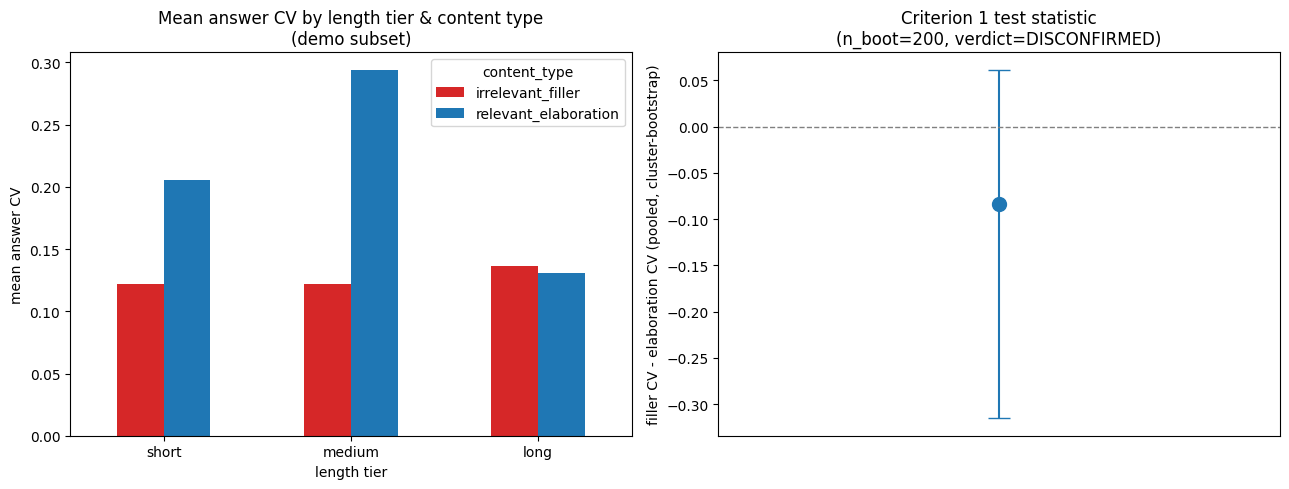

In [15]:
print("=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"{'n_prompt_cells_evaluated':40s} {len(agg)}")
print(f"{'n_seed_problems':40s} {agg['seed_problem_id'].nunique()}")
print(f"{'n_models':40s} {agg['model_id'].nunique()}")
print(f"{'n_cells_excluded_cv_undefined':40s} {exclusions['n_cells_excluded_cv_undefined']}")
po = m1.get("pooled_overall") or {}
boot = po.get("cluster_bootstrap_mean_diff_ci", {})
print(f"{'criterion1_pooled_mean_cv_diff':40s} {boot.get('mean'):.4f}")
print(f"{'criterion1_pooled_ci_lo/hi':40s} [{boot.get('ci_lo'):.4f}, {boot.get('ci_hi'):.4f}]")
print(f"{'length_match_violated':40s} {m4['length_match_violated']}")
print(f"{'FINAL VERDICT':40s} {verdict}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

pivot = (
    agg[agg["content_type"].isin(["irrelevant_filler", "relevant_elaboration"])]
    .groupby(["length_tier", "content_type"])["answer_cv"]
    .mean()
    .unstack("content_type")
)
tier_order = [t for t in ["short", "medium", "long"] if t in pivot.index]
pivot = pivot.reindex(tier_order)
pivot.plot(kind="bar", ax=axes[0], color=["#d62728", "#1f77b4"])
axes[0].set_title("Mean answer CV by length tier & content type\n(demo subset)")
axes[0].set_xlabel("length tier")
axes[0].set_ylabel("mean answer CV")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="content_type")

mean_ = boot.get("mean", 0.0)
lo, hi = boot.get("ci_lo", 0.0), boot.get("ci_hi", 0.0)
axes[1].errorbar([0], [mean_], yerr=[[mean_ - lo], [hi - mean_]], fmt="o", color="#1f77b4", capsize=8, markersize=10)
axes[1].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[1].set_xlim(-1, 1)
axes[1].set_xticks([])
axes[1].set_ylabel("filler CV - elaboration CV (pooled, cluster-bootstrap)")
axes[1].set_title(f"Criterion 1 test statistic\n(n_boot={N_BOOT_PAIRED}, verdict={verdict})")

plt.tight_layout()
plt.show()